In [1]:
!pip install datasets

Importing Libraries

In [18]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

Loading the dataset

In [19]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

Checking dataset

In [20]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


Converting Labels to Emotional Name

In [21]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Label Encoding

In [22]:
emotion_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

Tokenization

In [23]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

Converting tokens to sequences

In [24]:
vocab_size = 10000

tokenizer  = Tokenizer(num_words=vocab_size, oov_token="<OOV>")  #oov is out of vocabulary
tokenizer.fit_on_texts(train_df["text"])

train_sequences = tokenizer.texts_to_sequences(train_df["text"])

Padding

In [26]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

Building the model

In [27]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

Compiling the model

In [28]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training the model

In [29]:
Model: "sequential"

Accuracy Plot

In [30]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Loss Plot

In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3284 - loss: 1.6011 - val_accuracy: 0.3262 - val_loss: 1.5799
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.3883 - loss: 1.3562 - val_accuracy: 0.4263 - val_loss: 1.1992
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.4418 - loss: 1.0782 - val_accuracy: 0.4344 - val_loss: 1.1063
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4805 - loss: 0.9892 - val_accuracy: 0.4644 - val_loss: 1.1134
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5145 - loss: 0.8974 - val_accuracy: 0.5138 - val_loss: 0.9982
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.6227 - loss: 0.7572 - val_accuracy: 0.6759 - val_loss: 0.9124
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7691 - loss: 0.5295 - val_accuracy: 0.7547 - val_loss: 0.7133
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.8202 - loss: 0.3855 - val_accurac

Evaluation Of Model

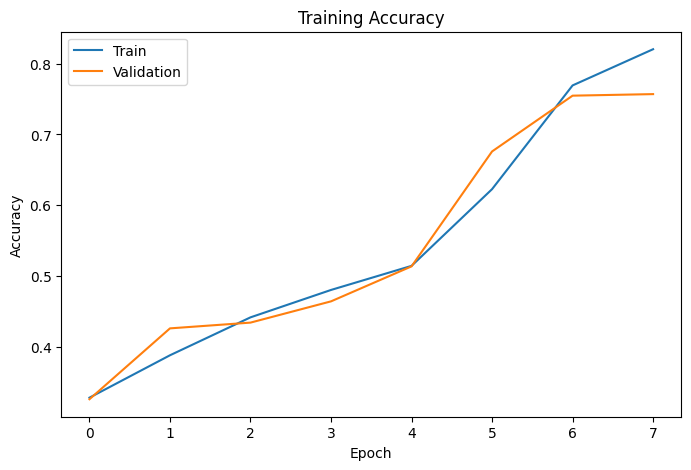

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

Classification Model

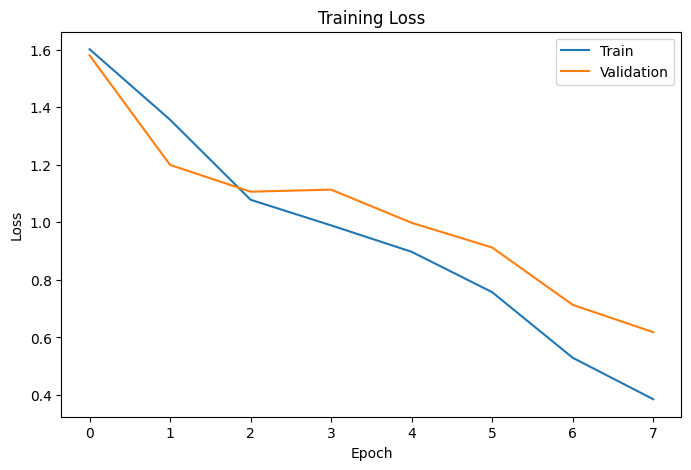

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

Predicting your own sentence

In [17]:
sentence = ["I feel like killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Emotion: anger


In [34]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7470 - loss: 0.6496
Test Accuracy : 0.746999979019165


In [35]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0       0.37      0.21      0.27       275
           1       0.42      0.74      0.53       224
           2       0.88      0.92      0.90       695
           3       0.70      0.78      0.74       159
           4       0.98      0.83      0.90       581
           5       0.45      0.32      0.37        66

    accuracy                           0.75      2000
   macro avg       0.63      0.63      0.62      2000
weighted avg       0.76      0.75      0.74      2000



In [36]:
sentence = ["I feel like killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Emotion: anger
